In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score
)

In [225]:
df = pd.read_csv('00.dataset/Mall_Customers.csv')
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


# 1.Clusstering KMeans++ KMeans

In [226]:
df = df.drop(columns='CustomerID')

In [227]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas") # Tambahkan baris ini sebelum fit_transform
X_cleaned = preprocessor.fit_transform(df)
X_cleaned.head()

,num__Age,num__Annual Income (k$),num__Spending Score (1-100),cat__Gender_Female,cat__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


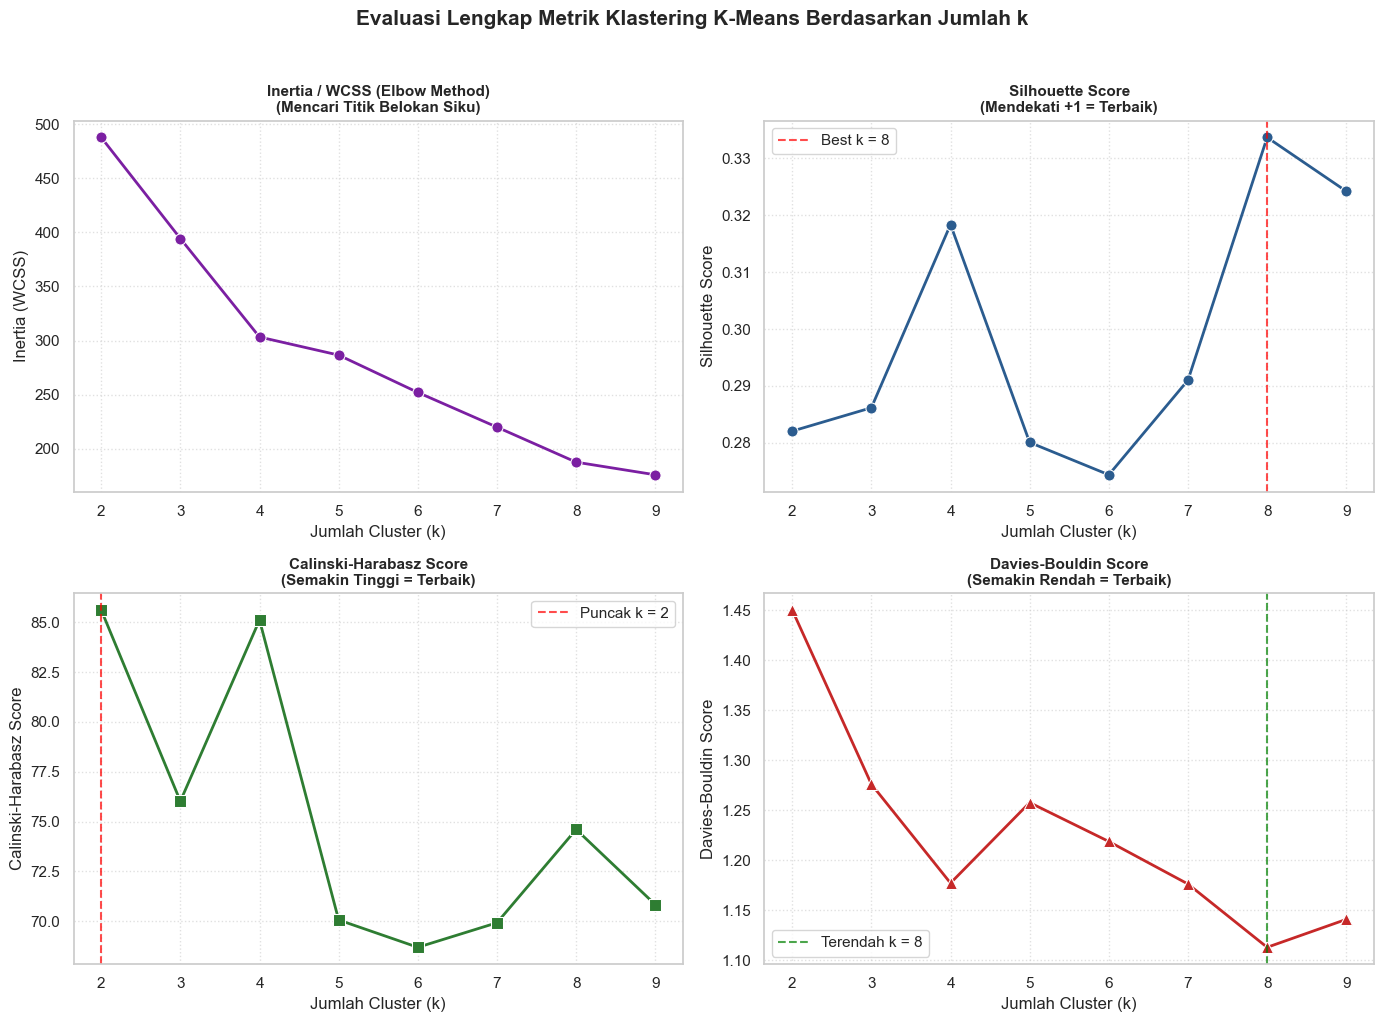

,n_clusters(k),Inertia (WCSS),Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,2,487.658634,0.282065,85.630536,1.450183
1,3,394.272069,0.286173,76.019489,1.275921
2,4,303.340667,0.318361,85.122106,1.177019
3,5,286.645244,0.280079,70.054692,1.257506
4,6,252.174440,0.274392,68.681662,1.218607
5,7,220.121115,0.291022,69.915074,1.176091
6,8,187.788990,0.333670,74.603517,1.112809
7,9,176.113905,0.324209,70.825756,1.140736


In [228]:
sil_scores = []
ch_scores = []
db_scores = []
inertias = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k,init='k-means++',random_state=42).fit(X_cleaned)
    model_kmeans = kmeans.labels_
    # Hitung 4 metrik evaluasi
    sil_scores.append(silhouette_score(X_cleaned, model_kmeans))
    ch_scores.append(calinski_harabasz_score(X_cleaned, model_kmeans))
    db_scores.append(davies_bouldin_score(X_cleaned, model_kmeans))
    inertias.append(kmeans.inertia_)

df_scores = pd.DataFrame({
    'n_clusters(k)': list(k_range),
    'Inertia (WCSS)': inertias,
    'Silhouette Score': sil_scores,
    'Calinski-Harabasz Score': ch_scores,
    'Davies-Bouldin Score': db_scores
})
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Inertia / Elbow Method (Cari titik belokan "siku")
sns.lineplot(ax=axes[0, 0], x='n_clusters(k)', y='Inertia (WCSS)', data=df_scores, marker='o', markersize=8, linewidth=2, color='#7b1fa2')
axes[0, 0].set_title('Inertia / WCSS (Elbow Method)\n(Mencari Titik Belokan Siku)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Cluster (k)')
axes[0, 0].set_xticks(list(k_range))
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Silhouette Score (Mendekati +1 Lebih Baik)
best_k_sil = int(df_scores.loc[df_scores['Silhouette Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[0, 1], x='n_clusters(k)', y='Silhouette Score', data=df_scores, marker='o', markersize=8, linewidth=2, color='#2b5c8f')
axes[0, 1].axvline(x=best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Best k = {best_k_sil}')
axes[0, 1].set_title('Silhouette Score\n(Mendekati +1 = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Cluster (k)')
axes[0, 1].set_xticks(list(k_range))
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
axes[0, 1].legend()

# Plot 3: Calinski-Harabasz Score (Makin Tinggi Lebih Baik)
best_k_ch = int(df_scores.loc[df_scores['Calinski-Harabasz Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[1, 0], x='n_clusters(k)', y='Calinski-Harabasz Score', data=df_scores, marker='s', markersize=8, linewidth=2, color='#2e7d32')
axes[1, 0].axvline(x=best_k_ch, color='red', linestyle='--', alpha=0.7, label=f'Puncak k = {best_k_ch}')
axes[1, 0].set_title('Calinski-Harabasz Score\n(Semakin Tinggi = Terbaik)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Jumlah Cluster (k)')
axes[1, 0].set_xticks(list(k_range))
axes[1, 0].grid(True, linestyle=':', alpha=0.6)
axes[1, 0].legend()

# Plot 4: Davies-Bouldin Score (Makin Rendah Lebih Baik)
best_k_db = int(df_scores.loc[df_scores['Davies-Bouldin Score'].idxmin(), 'n_clusters(k)'])
sns.lineplot(ax=axes[1, 1], x='n_clusters(k)', y='Davies-Bouldin Score', data=df_scores, marker='^', markersize=8, linewidth=2, color='#c62828')
axes[1, 1].axvline(x=best_k_db, color='green', linestyle='--', alpha=0.7, label=f'Terendah k = {best_k_db}')
axes[1, 1].set_title('Davies-Bouldin Score\n(Semakin Rendah = Terbaik)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Jumlah Cluster (k)')
axes[1, 1].set_xticks(list(k_range))
axes[1, 1].grid(True, linestyle=':', alpha=0.6)
axes[1, 1].legend()

plt.suptitle('Evaluasi Lengkap Metrik Klastering K-Means Berdasarkan Jumlah k', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
df_scores

In [229]:
best_kmeans = KMeans(n_clusters=2,init='k-means++', random_state=42)
df['Cluster'] = best_kmeans.fit_predict(X_cleaned)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,1
1,Male,21,15,81,1
2,Female,20,16,6,0
3,Female,23,16,77,1
4,Female,31,17,40,1


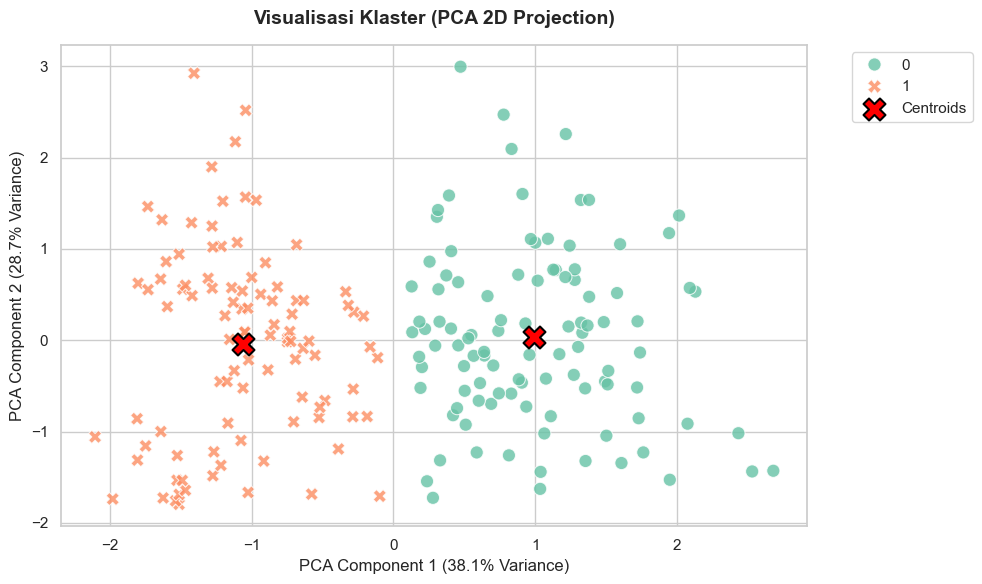

In [230]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cleaned)

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df['Cluster']
centroids_pca = pca.transform(best_kmeans.cluster_centers_)

sns.set_theme(style="whitegrid")
palette = 'Set2'

plt.figure(figsize=(10, 6))
sns.scatterplot( x='PCA1', y='PCA2', hue='Cluster', data=df_pca, palette=palette, s=90, alpha=0.8, style='Cluster')
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=250, c='red', marker='X', edgecolor='black', linewidth=1.5, label='Centroids') # Plot Centroid sebagai tanda silang 'X' merah besar
plt.title('Visualisasi Klaster (PCA 2D Projection)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()